<a href="https://colab.research.google.com/github/nanna273/MLEndLS_AB/blob/main/ECS7020P_miniproject_advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECS7020P mini-project submission

The mini-project has two separate components:


~~1.   **Basic component** [6 marks]: Using the MLEnd London Sounds dataset, build a machine learning pipeline that takes as an input an audio segment and predicts whether the audio segment has been recorded indoors or outdoors.~~  
2.   **Advanced component** [10 marks]: Formulate your own machine learning problem and build a machine learning solution using the MLEnd London Sounds dataset.  

Your submission will consist of two Jupyter notebooks, one for the basic component and another one for advanced component. Please **name each notebook**:

* ECS7020P_miniproject_basic.ipynb
* ECS7020P_miniproject_advanced.ipynb

then **zip and submit them toghether**.

Each uploaded notebook should include: 

*   **Text cells**, describing concisely each step and results.
*   **Code cells**, implementing each step.
*   **Output cells**, i.e. the output from each code cell.

and **should have the structure** indicated below. Notebooks might not be run, please make sure that the output cells are saved.

How will we evaluate your submission?

*   Conciseness in your writing (10%).
*   Correctness in your methodology (30%).
*   Correctness in your analysis and conclusions (30%).
*   Completeness (10%).
*   Originality (10%).
*   Efforts to try something new (10%).

Suggestion: Why don't you use **GitHub** to manage your project? GitHub can be used as a presentation card that showcases what you have done and gives evidence of your data science skills, knowledge and experience. 

Each notebook should be structured into the following 9 sections:


# 1 Author

**Student Name**:  Anna Burlingsby  
**Student ID**:  210900587



# 2 Problem formulation

Describe the machine learning problem that you want to solve and explain what's interesting about it.  

London is a vibrant city, full of both natural and man-made noises. It is supposed that areas might be distinguished via recordings made in those areas.  

The areas selected for investigation in this notebook are museums/libraries vs. train stations. These are indoor spaces, but are used for quite different purposes - libraries and museums have an expectation of quiet contemplation, whereas stations are busy hubs full of noise. Classification as 'busy' or not is the purpose of this notebook.

# 3 Machine Learning pipeline

Describe your ML pipeline. Clearly identify its input and output, any intermediate stages (for instance, transformation -> models), and intermediate data moving from one stage to the next. It's up to you to decide which stages to include in your pipeline.  

Below, the libraries that will be used to address this problem are imported.

In [1]:
from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os, sys, re, pickle, glob
import urllib.request
import zipfile

import IPython.display as ipd
from tqdm import tqdm
import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


## 3.1 Overview  

Broadly, the pipeline is divided into the following stages:  
1. Load data, where the raw data is brought into the notebook.
2. Sampling, where a subset of the data is selected to work with.
2. Transformation, where the audio files are processed to extract features.
4. Validation, where models are compared, and one is selected.
3. Testing, where the selected model is tested before deployment.
6. Training, where the model is re-trained on the whole dataset.
4. Deployment, not covered in this notebook, where models are deployed on unseen data.

# 4 Transformation stage

Describe any transformations, such as feature extraction. Identify input and output. Explain why you have chosen this transformation stage.

## 4.1 Basic features

Several basic features of each recording are extracted:  
- Overall power of the recording.
- Mean of the pitch of the recording.
- Standard deviation of the pitch.
- Fraction of the recording that is voiced.  

## 4.2 More advanced features  

The Python Librosa library contains a range of features that describe audio data. The following will be explored in this notebook:
- Spectral contrast
- Chroma
- MFCC
- RMS
- Spectral centroid
- Spectral bandwidth
- Spectral flatness
- Spectral rolloff.

Due to the time constraints of producing this notebook, any further description of the meaning of each of the advanced features will not be conducted.

# 5 Modelling

Describe the ML model(s) that you will build. Explain why you have chosen them.  

Models should be selected that can make binary classifications of samples. This includes:
- Support Vector Machines (SVM)
- Logistic Regression
- Random Forest.

# 6 Methodology

Describe how you will train and validate your models, how model performance is assesssed (i.e. accuracy, confusion matrix, etc)

As the MLEndLS dataset is fairly evenly balanced in terms of indoor and outdoor locations, accuracy is likely to be a fairly good estimator of model performance.

# 7 Dataset

Describe the dataset that you will use to create your models and validate them. If you need to preprocess it, do it here. Include visualisations too. You can visualise raw data samples or extracted features.

## 7.1 Dataset reduction

### 7.1.1 Introduction to dataset    

A dataset of audio recordings from around London has been collected by students at Queen Mary University of London (QMUL), and is called MLEndLS. The attributes of this raw data are:  
1. file_id - the name of the file e.g. '0001.wav' that will be used as an index.
2. area - the area of London where the file was recorded e.g. 'british' = The British Museum.
3. spot - the spot in the area where the recording was made e.g. 'street' = Great Russel Street.
4. in_out - whether the spot is 'indoor' or 'outdoor'.
5. Participant - the ID of the student who made the recording e.g. 'S151'.
6. Audio file recording - the .wav file that contains the approximately 7 second clip recorded by the participant.

The following is known about how the data was collected:  
- Participants were given the choice of 6 areas they could make recordings in.
- Each area contained 6 spots.
- Participants selected a minimum of 3 areas, and made recordings in all 6 spots of each of those areas. (note: one area, 'british' has only 5 spots, as the proposed spot 'room23' was inaccessible at the time of the recordings').

### 7.1.2 Dataset for advanced problem

For the solution to this problem, only certain spots in the dataset are relevant:  

**Museums/libraries (not busy):**  
- Indoors: British Museum, Great court (british, greatcourt).
- Indoors: British Museum, Room 12 (british, room12).
- ~~Indoors: British Museum, Room 23 (british, room23).~~ excluded due to lack of recordings in this location.
- Indoors: The National Gallery Central Hall (westend, national).
- Indoors: Royal Festival Hall welcome hub (southbank, royal).
- Indoors: Natural History Museum Hintze Hall (kensington, hintze).
- Indoors: Natural History Museum Fossil Marine Reptiles gallery (kensington, marine).
- Indoors: Natural History Museum Dinosaur gallery (kensington, dinosaur).
- Indoors: British Library main entrance (euston, library).
- Indoors: British Library, John Ritblat gallery (euston, ritblat).  

**Train stations (busy):**  
- Indoors: Charing Cross station foyer (westend, charing).
- Indoors: Waterloo Station foyer (southbank, waterloo).
- Indoors: St Pancras International, upper level (euston, upper).

Note that there are approximately 3x more locations that are 'not busy' as 'busy'. The problem formulation will address this.

## 7.2 Uploading data to notebook  

Below, the filenames are loaded into the notebook and the number of MLEndLS audio files is checked.

In [3]:
sample_path = '/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/*.wav'
files = glob.glob(sample_path)
len(files)

2497

There are 2500 files in the MLEndLS dataset, which has been manually chnaged to 2497 after the removal of 3 files. Two do not contain data (see section 7.3 below), and one is known to be a mislabelled location ('room13').

The attributes of each file have been provided in a .csv file, and are loaded into a dataframe below.

In [4]:
MLEndLS_df = pd.read_csv('/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/MLEndLS.csv').set_index('file_id') 
MLEndLS_df

,area,spot,in_out,Participant
file_id,,,,
0001.wav,british,street,outdoor,S151
0002.wav,kensington,dinosaur,indoor,S127
0003.wav,campus,square,outdoor,S18
0004.wav,kensington,hintze,indoor,S179
0005.wav,campus,square,outdoor,S176
...,...,...,...,...
2496.wav,westend,trafalgar,outdoor,S151
2497.wav,campus,square,outdoor,S6
2498.wav,westend,national,indoor,S96


Below, the desired locations are selected, and the 'busy' vs. 'not busy' classification is added.  

**Museums/libraries (not busy):**  
- Indoors: British Museum, Great court (british, greatcourt).
- Indoors: British Museum, Room 12 (british, room12).
- ~~Indoors: British Museum, Room 23 (british, room23).~~ excluded due to lack of recordings in this location.
- Indoors: The National Gallery Central Hall (westend, national).
- Indoors: Royal Festival Hall welcome hub (southbank, royal).
- Indoors: Natural History Museum Hintze Hall (kensington, hintze).
- Indoors: Natural History Museum Fossil Marine Reptiles gallery (kensington, marine).
- Indoors: Natural History Museum Dinosaur gallery (kensington, dinosaur).
- Indoors: British Library main entrance (euston, library).
- Indoors: British Library, John Ritblat gallery (euston, ritblat).  

**Train stations (busy):**  
- Indoors: Charing Cross station foyer (westend, charing).
- Indoors: Waterloo Station foyer (southbank, waterloo).
- Indoors: St Pancras International, upper level (euston, upper).

In [5]:
busy = ['westendcharing', 'southbankwaterloo', 'eustonupper']
not_busy = ['britishgreatcourt', 'britishroom12', 'westendnational',
            'southbankroyal', 'kensingtonhintze', 'kensingtonmarine',
            'kensingtondinosaur', 'eustonlibrary']
advanced_list = busy + not_busy

MLEndLS_df['area_spot'] = MLEndLS_df['area'] + MLEndLS_df['spot']#
MLEndLS_df_a = MLEndLS_df.loc[MLEndLS_df['area_spot'].isin(advanced_list)]
MLEndLS_df_a['busy'] = MLEndLS_df_a['area_spot'].isin(busy)

# Drop some extraneous columns
#MLEndLS_df_a = MLEndLS_df_a.drop(['in_out', 'Participant'], axis=1)
MLEndLS_df_a

<ipython-input-5-8bc3919fb9f3>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MLEndLS_df_a['busy'] = MLEndLS_df_a['area_spot'].isin(busy)


,area,spot,in_out,Participant,area_spot,busy
file_id,,,,,,
0002.wav,kensington,dinosaur,indoor,S127,kensingtondinosaur,False
0004.wav,kensington,hintze,indoor,S179,kensingtonhintze,False
0013.wav,british,greatcourt,indoor,S66,britishgreatcourt,False
0019.wav,kensington,dinosaur,indoor,S82,kensingtondinosaur,False
0024.wav,southbank,waterloo,indoor,S41,southbankwaterloo,True
...,...,...,...,...,...,...
2483.wav,kensington,dinosaur,indoor,S19,kensingtondinosaur,False
2491.wav,westend,national,indoor,S147,westendnational,False
2498.wav,westend,national,indoor,S96,westendnational,False


Summary statistics about the dataframe are presented below.

In [6]:
MLEndLS_df_a.describe(include='all')

,area,spot,in_out,Participant,area_spot
count,539,539,539,539,539
unique,4,9,1,171,9
top,westend,charing,indoor,S178,westendcharing
freq,223,113,539,6,113


## 7.3 Data cleaning ##  

Some of the audio files do not contain any information. Below is some code that will identify these files, by opening them and using the librosa library to calculate the sum of their amplitude. Files with a zero amplitude are removed from the dataset.

In [ ]:
# for n, file in enumerate(files):
#   fs = None # Sampling frequency
#   x, fs = librosa.load(files[n], sr=fs)
#   empty_filenames = []
#   if x.sum() == 0:
#     print(file)

Output of above cell:  

```
/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/2206.wav  
/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/0033.wav
```

The empty files are '2206.wav' and '0033.wav'. These have manually been removed from the Google Drive folder, and the above code will not be run for future executions of this notebook.  

The empty file in the non-existent 'room13' is identified as '0762.wav' below. It has also been manually removed.

In [7]:
MLEndLS_df.loc[MLEndLS_df.spot=='room13']

,area,spot,in_out,Participant,area_spot
file_id,,,,,


In [6]:
to_drop = ['2206.wav', '0033.wav', '0762.wav']
MLEndLS_df = MLEndLS_df.drop(to_drop)

In [8]:
files_a = [file for file in files
                if file.split('/')[-1] in MLEndLS_df_a.index]

## 7.4 Data visualisation  

Below is a code cell that previews an audio file.

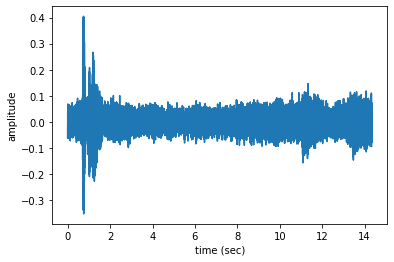

In [14]:
n = 1
fs = None # Sampling frequency
fs = 22050
x, fs = librosa.load(files_a[n],sr=fs)
t = np.arange(len(x))/fs
plt.plot(t,x)
plt.xlabel('time (sec)')
plt.ylabel('amplitude')
plt.show()
display(ipd.Audio(files_a[n]))

According to the instructions, each audio file should contain the participant saying 'this is London' at the start of the recording. This can be seen in the above representative example as the considerably higher peaks early in the audio signal.  

Below, the signal undergoes a Fast Fourier Transform (FFT) to transfrom it into the frequency domain.

Text(0, 0.5, 'Amplitude')

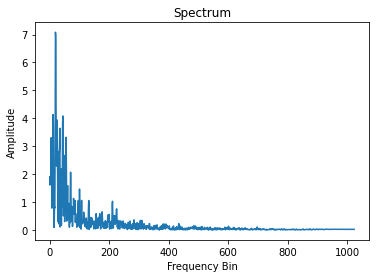

In [15]:
n_fft = 2048
ft = np.abs(librosa.stft(x[:n_fft], hop_length=n_fft+1))
plt.plot(ft)
plt.title('Spectrum')
plt.xlabel('Frequency Bin')
plt.ylabel('Amplitude')

https://analyticsindiamag.com/a-tutorial-on-spectral-feature-extraction-for-audio-analytics/

"Mel scale is the scale of pitches that can be felt by the listener to be equal in distance from one another. For example, a listener can identify the difference between the audio of 10000 Hz and 15000 Hz if the audio sources are in the same distance and atmosphere.  Representation of frequencies into the Mel scale generates the Mel spectrogram. Frequencies can be converted into the Mel scale using the Fourier transform."

Text(0.5, 1.0, 'Spectrogram')

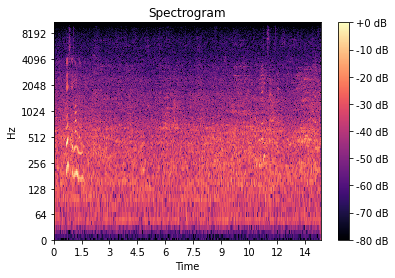

In [16]:
spec = np.abs(librosa.stft(x, hop_length=512))
spec = librosa.amplitude_to_db(spec, ref=np.max)
librosa.display.specshow(spec, sr=fs, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')

The Mel spectrogram is an image of the data as it appears to human ears. One thing that is clear is that the data is not equivariate, and therefore a convolutional neural network should not be used on the raw data. However, the time domain should not be worked in (the time of sounds is arbitrary), and thus the sound should be transformed to the frequency domain for feature extraction.

## 7.5 Feature extraction  

The features that will be used to predict whether sound was recorded indoors or outdoors are extracted from audio recordings.  

### 7.5.1 Basic features  

First, the librosa library is used to extract the pitch, as well as the portions to the recording that contain voices.  

https://arxiv.org/ftp/arxiv/papers/2204/2204.12177.pdf

https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=8405119

https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=9640566


In [9]:
def getPitch(x,fs,winLen=0.02):
  #winLen = 0.02 
  p = winLen*fs
  frame_length = int(2**int(p-1).bit_length())
  hop_length = frame_length//2
  f0, voiced_flag, voiced_probs = librosa.pyin(y=x, fmin=80, fmax=450, sr=fs,
                                                 frame_length=frame_length,hop_length=hop_length)
  return f0,voiced_flag

In [10]:
def getXy_basic(files,labels_file, scale_audio=False, onlySingleDigit=False):
  X_1, X_2, y =[], [], []
  for file in tqdm(files):
    fileID = file.split('/')[-1]
    file_name = file.split('/')[-1]
    yi = labels_file.loc[fileID]['busy']

    fs = None # if None, fs would be 22050
    x, fs = librosa.load(file,sr=fs)

    # Without scaled audio
    f0, voiced_flag = getPitch(x,fs,winLen=0.02)
      
    power = np.sum(x**2)/len(x)
    pitch_mean = np.nanmean(f0) if np.mean(np.isnan(f0))<1 else 0
    pitch_std  = np.nanstd(f0) if np.mean(np.isnan(f0))<1 else 0
    voiced_fr = np.mean(voiced_flag)

    xi1 = [power,pitch_mean,pitch_std,voiced_fr]
    X_1.append(xi1)

    # With scaled audio
    x = x/np.max(np.abs(x))
    f0, voiced_flag = getPitch(x,fs,winLen=0.02)
      
    power = np.sum(x**2)/len(x)
    pitch_mean = np.nanmean(f0) if np.mean(np.isnan(f0))<1 else 0
    pitch_std  = np.nanstd(f0) if np.mean(np.isnan(f0))<1 else 0
    voiced_fr = np.mean(voiced_flag)

    xi2 = [power,pitch_mean,pitch_std,voiced_fr]

    X_2.append(xi2)
    y.append(yi)

  return np.array(X_1), np.array(X_2), np.array(y)

In [34]:
# fileID = [file.split('/')[-1] for file in files_a]

In [35]:
# X_1, X_2, y_1 = getXy_basic(files_a, labels_file=MLEndLS_df_a, scale_audio=True, onlySingleDigit=True)

100%|██████████| 539/539 [14:39<00:00,  1.63s/it]


In [36]:
# df_basic_scaled = pd.DataFrame(X_1, index=fileID)
# df_basic_scaled['busy'] = y_1
# df_basic_scaled = df_basic_scaled.rename(
#     columns={0:'power', 1:'pitch_mean', 2:'pitch_std', 3:'voiced_fr'})

# df_basic_unscaled = pd.DataFrame(X_2, index=fileID)
# df_basic_unscaled['busy'] = y_1
# df_basic_unscaled = df_basic_unscaled.rename(
#     columns={0:'power', 1:'pitch_mean', 2:'pitch_std', 3:'voiced_fr'})
# df_basic_unscaled

,power,pitch_mean,pitch_std,voiced_fr,busy
1504.wav,0.006184,162.432598,14.204691,0.091057,True
1505.wav,0.006024,195.189920,22.814062,0.042846,True
1515.wav,0.011014,132.463064,19.980140,0.059740,True
1531.wav,0.002208,133.074084,21.050847,0.052531,False
1532.wav,0.008542,124.728313,14.096215,0.065740,False
...,...,...,...,...,...
0483.wav,0.015817,132.159882,8.819580,0.071429,False
0485.wav,0.006001,233.313437,29.249193,0.089013,True
0489.wav,0.012387,0.000000,0.000000,0.000000,True
0491.wav,0.008435,254.176308,6.404413,0.025145,False


### 7.5.2 STFT  

A number of features can be extracted from the data via the librosa library. Due to the time constraints of this project, domain understanding of these will not be sought. Other methods will be used to determine useful potential features for model fitting. The 'librosa.feature' methods give a total of 44 potential features to investigate. The code is run twice, once with, and once without audio scaling. Both will be investigated.

In [37]:
def getXy_STFT(files,labels_file, scale_audio=False):
  X,y =[],[]
  for file in tqdm(files):
    fileID = file.split('/')[-1]
    file_name = file.split('/')[-1]

    fs = 22050 # if None, fs would be 22050
    x, fs = librosa.load(file,sr=fs)
    if scale_audio: x = x/np.max(np.abs(x))
    n_fft = 2048
    ft = np.abs(librosa.stft(x[:n_fft], hop_length=n_fft+1))
    sc = librosa.feature.spectral_contrast(S=ft, sr=fs) # features 0-6
    ch = librosa.feature.chroma_stft(S=ft, sr=fs) # features 7-19
    mf = librosa.feature.mfcc(S=ft, sr=fs) # features 20-39
    rm = librosa.feature.rms(S=ft) # feature 40
    st = librosa.feature.spectral_centroid(S=ft, sr=fs) # feature 41
    sb = librosa.feature.spectral_bandwidth(S=ft, sr=fs) # features 42
    sf = librosa.feature.spectral_flatness(S=ft) # feature 43
    sr = librosa.feature.spectral_rolloff(S=ft, sr=fs) # feature 44

    features = [sc.T, ch.T, mf.T, rm.T, st.T, sb.T, sf.T, sr.T]

    xi = np.concatenate((features), axis=1)[0]

    X.append(xi)

  return np.array(X)

In [38]:
# X_3 = getXy_STFT(files_a, labels_file=MLEndLS_df_a, scale_audio=True)

  1%|▏         | 8/539 [00:05<05:26,  1.63it/s]/usr/local/lib/python3.8/dist-packages/librosa/core/pitch.py:153: UserWarning: Trying to estimate tuning from empty frequency set.
  warnings.warn("Trying to estimate tuning from empty frequency set.")
100%|██████████| 539/539 [05:03<00:00,  1.78it/s]


In [39]:
# df_stft_scaled = pd.DataFrame(X_3,index=fileID)

In [40]:
# X_4 = getXy_STFT(files_a, labels_file=MLEndLS_df_a, scale_audio=False)

100%|██████████| 539/539 [06:06<00:00,  1.47it/s]


In [41]:
# df_stft_unscaled = pd.DataFrame(X_4, index=fileID)
# df_stft_unscaled

,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
1504.wav,18.349005,9.555354,22.610567,27.337812,23.719855,31.919293,19.603334,0.520229,0.470488,0.580427,...,-0.696106,-1.106333,-1.069302,-7.963592e-01,-6.698915e-01,2.098166e-02,1802.247512,1985.886511,0.009420,3197.680664
1505.wav,16.587177,18.209691,16.249774,16.904838,18.433717,27.076254,21.439117,0.863348,0.855988,0.890087,...,0.503841,0.445847,0.365332,2.534384e-01,1.985624e-01,1.435344e-02,1431.810275,1977.153182,0.006195,2842.382812
1515.wav,11.762277,17.963004,35.828825,26.720717,23.592464,26.839473,52.107978,0.647491,0.590788,0.583206,...,0.299300,0.175212,0.070362,1.626243e-02,-3.232723e-04,3.152412e-03,1081.626100,1714.314167,0.001185,2174.853516
1531.wav,18.109955,14.275800,20.413946,17.777177,21.301632,28.000415,49.630094,0.930514,0.861072,0.831439,...,-0.003354,-0.015305,-0.010110,2.052462e-03,3.475000e-04,4.917125e-04,1418.050322,1643.669755,0.003061,3143.847656
1532.wav,21.984720,10.796778,16.865395,18.507653,25.763406,22.504553,34.512151,0.843230,0.814503,0.687101,...,-0.032032,-0.324249,-0.495422,-5.578328e-01,-7.070091e-01,1.768000e-02,1108.012758,1390.052970,0.000655,2153.320312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0483.wav,19.792759,9.966521,25.944634,19.047873,18.923113,25.313077,25.511533,0.784158,0.996292,0.669891,...,-0.883308,-1.159248,-1.104367,-8.146042e-01,-1.081740e+00,1.328110e-02,1870.791382,2161.930228,0.011552,3692.944336
0485.wav,16.914389,19.885105,18.255779,21.654172,21.563360,27.489999,50.043262,0.977431,0.941717,0.971521,...,-0.007741,-0.012348,-0.013197,-1.326102e-02,-1.365378e-02,9.796335e-05,1703.558969,1830.788701,0.005545,3456.079102
0489.wav,2.048830,16.147219,17.955252,19.820933,18.017798,24.700870,27.840895,0.627858,0.717409,0.767459,...,0.000002,0.000002,0.000002,9.346567e-07,1.360839e-07,7.263366e-09,3541.420116,2566.475040,1.000001,6492.260742
0491.wav,17.697577,30.877082,28.484881,24.694003,27.406281,25.942732,53.662472,0.811939,1.000000,0.991419,...,-0.798448,-0.948832,-1.023078,-1.067186e+00,-1.132565e+00,8.386265e-03,1237.027666,1504.589535,0.000820,2336.352539


### 7.5.3 Combining features  

Below the basic and FFT features are combined into 2 dataframes, one with scaled audio and one without. Each of these is saved to a '.csv' file, so that repeated iterations of the notebook will not need to run the functions. The files have been manually renamed in the folder to avoid accidentally writing over them.

In [42]:
# df_scaled = pd.concat([df_stft_scaled, df_basic_scaled], axis=1)
# df_scaled.to_csv('/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/scaled_features.csv')

In [43]:
# df_unscaled = pd.concat([df_stft_unscaled, df_basic_unscaled], axis=1)
# df_unscaled.to_csv('/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/unscaled_features.csv')

In [ ]:
# fig, axs = plt.subplots(9, 5, figsize=(20,15))

# for i in range(44):
#   axs[i//5, i%5].hist(df_unscaled.loc[:,i])

# plt.show()

## 7.6 Feature selection  

Not all the features will correlate with the target variable. A PCA will be conducted, and the coefficients analysed to select features for modelling.  

First, the feature data is re-introduced to the notebook.

In [45]:
scaled_path = '/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/scaled_features_a_221206.csv'
unscaled_path = '/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/unscaled_features_a_221206.csv'
df_scaled = pd.read_csv(scaled_path, index_col=0)
df_unscaled = pd.read_csv(unscaled_path, index_col=0)

In [46]:
df_unscaled

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,power,pitch_mean,pitch_std,voiced_fr,busy
1504.wav,18.349005,9.555354,22.610567,27.337812,23.719855,31.919293,19.603334,0.520229,0.470488,0.580427,...,2.098166e-02,1802.247512,1985.886511,0.009420,3197.680664,0.006184,162.432598,14.204691,0.091057,True
1505.wav,16.587177,18.209691,16.249774,16.904838,18.433717,27.076254,21.439117,0.863348,0.855988,0.890087,...,1.435344e-02,1431.810275,1977.153182,0.006195,2842.382812,0.006024,195.189920,22.814062,0.042846,True
1515.wav,11.762277,17.963004,35.828825,26.720717,23.592464,26.839473,52.107978,0.647491,0.590788,0.583206,...,3.152412e-03,1081.626100,1714.314167,0.001185,2174.853516,0.011014,132.463064,19.980140,0.059740,True
1531.wav,18.109955,14.275800,20.413946,17.777177,21.301632,28.000415,49.630094,0.930514,0.861072,0.831439,...,4.917125e-04,1418.050322,1643.669755,0.003061,3143.847656,0.002208,133.074084,21.050847,0.052531,False
1532.wav,21.984720,10.796778,16.865395,18.507653,25.763406,22.504553,34.512151,0.843230,0.814503,0.687101,...,1.768000e-02,1108.012758,1390.052970,0.000655,2153.320312,0.008542,124.728313,14.096215,0.065740,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0483.wav,19.792759,9.966521,25.944634,19.047873,18.923113,25.313077,25.511533,0.784158,0.996292,0.669891,...,1.328110e-02,1870.791382,2161.930228,0.011552,3692.944336,0.015817,132.159882,8.819580,0.071429,False
0485.wav,16.914389,19.885105,18.255779,21.654172,21.563360,27.489999,50.043262,0.977431,0.941717,0.971521,...,9.796335e-05,1703.558969,1830.788701,0.005545,3456.079102,0.006001,233.313437,29.249193,0.089013,True
0489.wav,2.048830,16.147219,17.955252,19.820933,18.017798,24.700870,27.840895,0.627858,0.717409,0.767459,...,7.263366e-09,3541.420116,2566.475040,1.000001,6492.260742,0.012387,0.000000,0.000000,0.000000,True
0491.wav,17.697577,30.877082,28.484881,24.694003,27.406281,25.942732,53.662472,0.811939,1.000000,0.991419,...,8.386265e-03,1237.027666,1504.589535,0.000820,2336.352539,0.008435,254.176308,6.404413,0.025145,False


### 7.6.1 Train test split  

To avoid data leakage, the dataset will be split before any further analysis or feature extraction.

In [ ]:
y = df_unscaled.pop('indoor')

In [ ]:
X = np.array(df_unscaled)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((280, 48), (70, 48), (280,), (70,))

### 7.6.2 Visualisations for feature reductions  

Below are presented some representations of how well each feature correlates with the target variable.

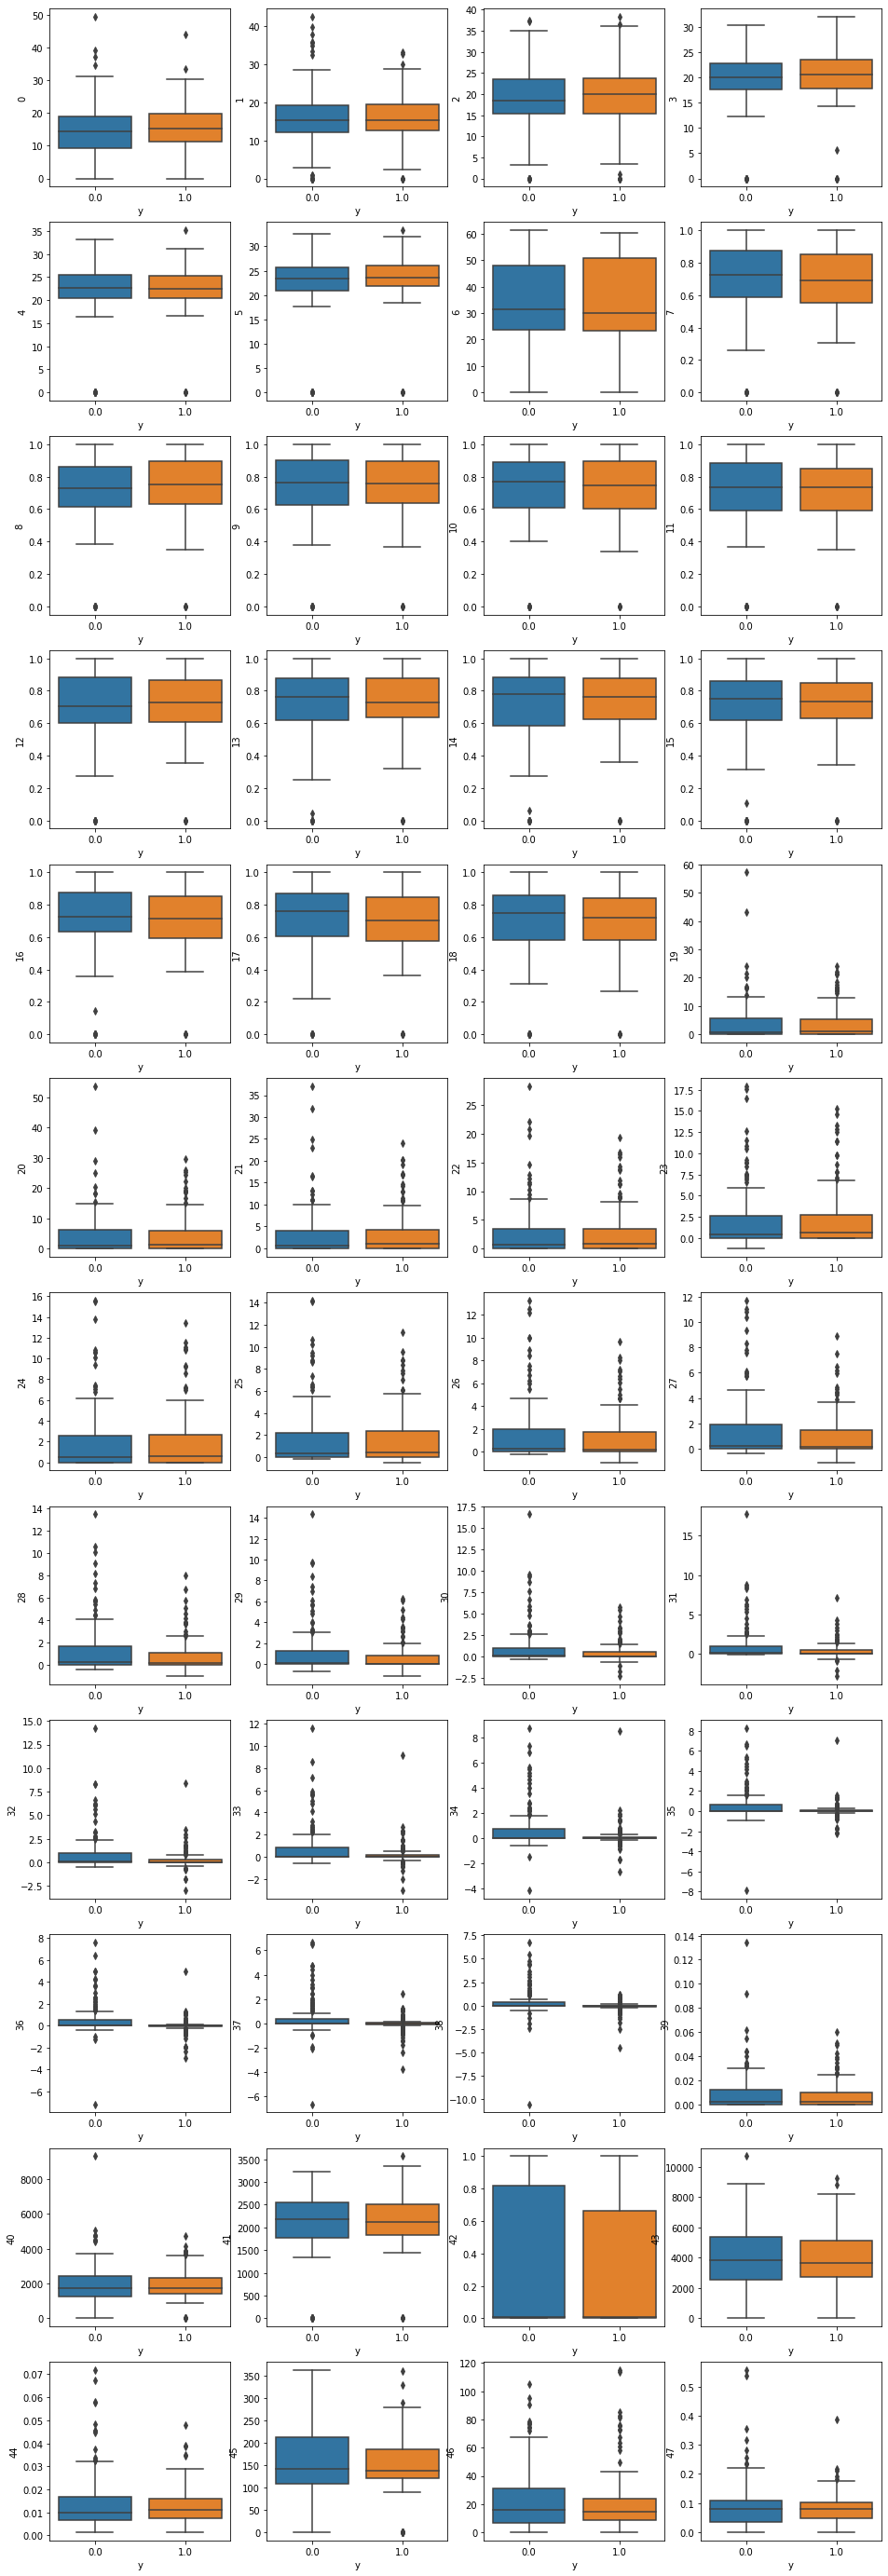

In [ ]:
data = pd.DataFrame(np.column_stack((X_train, y_train)))
data = data.rename(columns={48:'y'})

fig, axs = plt.subplots(12, 4, figsize=(16,50))

for i in range(48):
  sns.boxplot(data=data, y=i, x='y', ax=axs[i//4, i%4])

And now with the outliers (fliers) hidden.

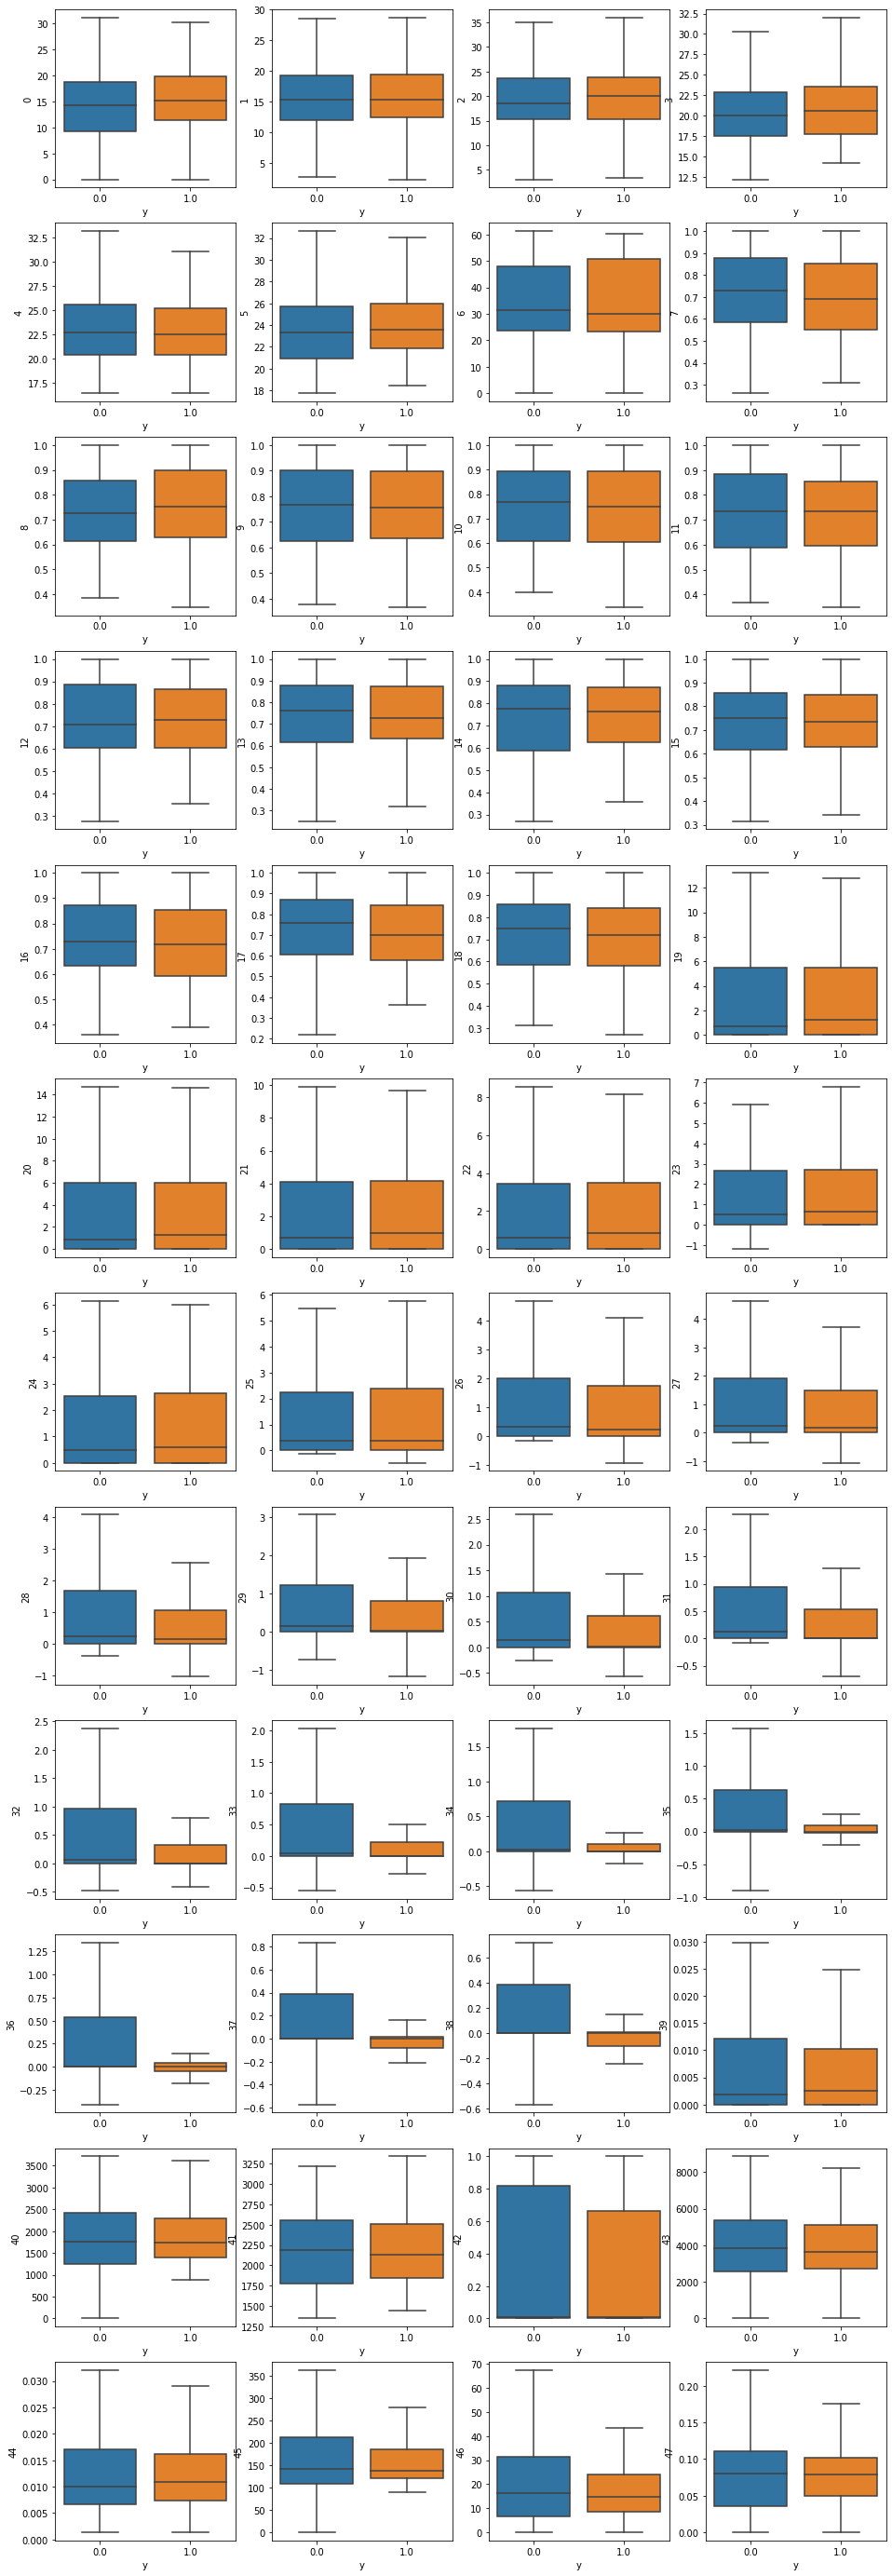

In [ ]:
fig, axs = plt.subplots(12, 4, figsize=(16,50))

for i in range(48):
  sns.boxplot(data=data, y=i, x='y', ax=axs[i//4, i%4], showfliers=False)

With the fliers hidden, there appears to be some correlation between 34-38 and the target variable (as well as maybe 28-33, but less so). Therefore, modelling with only these features will be compared to modelling with all features.

## 7.6.2 PCA  

A PCA with 2 components has been conducted on the reduced variables.

In [ ]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X_train.T[34:39].T)
pca = PCA(n_components=2)
pca = pca.fit(X_scaled)
print(pca.explained_variance_ratio_)
pca = pca.transform(X_scaled)

[0.88208752 0.10849534]


In [ ]:
df_pca = pd.DataFrame(data=pca, columns=['PC1', 'PC2'])

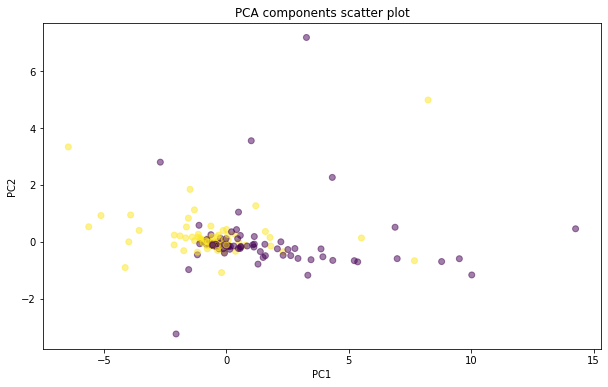

In [ ]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot()
p = ax.scatter(df_pca.PC1, df_pca.PC2,c=y_train.values, alpha=0.5)
ax.set_title('PCA components scatter plot')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.show()

While there appears to be some separation, the majority of the points are clustered closely together, and therefore the PCA is unlikely to represent good separation for modelling.

# 8 Results

Carry out your experiments here, explain your results.  

## 8.1 Model selection and validation  

Several machine learning models are compared using cross-validation.

In [ ]:
classifiers = {'SVC' : svm.SVC(C=100,gamma=0.001),
               'Random Forest' : RandomForestClassifier(),
               'Logistic Regression' : LogisticRegression(solver='liblinear')}

print('For the 48 extracted variables:')
for key, clf in classifiers.items():
  pipe = Pipeline(steps = [('scaler', StandardScaler()), ('classifier', clf)])
  scores = cross_val_score(pipe, X_train, y_train, cv=5)
  print('The cross-validation scores for', key, 'are:')
  print(scores)
  print(f'(mean = {scores.mean()})')

For the 48 extracted variables:
The cross-validation scores for SVC are:
[0.66071429 0.53571429 0.625      0.58928571 0.58928571]
(mean = 0.6)
The cross-validation scores for Random Forest are:
[0.60714286 0.58928571 0.60714286 0.60714286 0.66071429]
(mean = 0.6142857142857142)
The cross-validation scores for Logistic Regression are:
[0.625      0.5        0.60714286 0.625      0.64285714]
(mean = 0.6)


In [ ]:
classifiers = {'SVC' : svm.SVC(C=100,gamma=0.001),
               'Random Forest' : RandomForestClassifier(),
               'Logistic Regression' : LogisticRegression(solver='liblinear')}

X_train_1 = X_train.T[34:39].T

print('For variables extracted through PCA:')
for key, clf in classifiers.items():
  pca = PCA(n_components=2)
  pipe = Pipeline(steps = [('scaler', StandardScaler()), ('PCA', pca), ('classifier', clf)])
  scores = cross_val_score(pipe, X_train_1, y_train, cv=5)
  print('The cross-validation scores for', key, 'are:')
  print(scores)
  print(f'(mean = {scores.mean()})')

For variables extracted through PCA:
The cross-validation scores for SVC are:
[0.55357143 0.64285714 0.57142857 0.60714286 0.64285714]
(mean = 0.6035714285714285)
The cross-validation scores for Random Forest are:
[0.60714286 0.60714286 0.60714286 0.53571429 0.58928571]
(mean = 0.5892857142857142)
The cross-validation scores for Logistic Regression are:
[0.57142857 0.64285714 0.57142857 0.625      0.625     ]
(mean = 0.6071428571428571)


In [ ]:
classifiers = {'SVC' : svm.SVC(C=10,gamma=1),
               'Random Forest' : RandomForestClassifier(),
               'Logistic Regression' : LogisticRegression(solver='liblinear')}

X_train_1 = X_train.T[34:39].T

print('For the 8 selected variables:')
for key, clf in classifiers.items():
  pipe = Pipeline(steps = [('scaler', StandardScaler()), ('classifier', clf)])
  scores = cross_val_score(pipe, X_train_1, y_train, cv=5)
  print('The cross-validation scores for', key, 'are:')
  print(scores)
  print(f'(mean = {scores.mean()})')

For the 8 selected variables:
The cross-validation scores for SVC are:
[0.55357143 0.51785714 0.57142857 0.64285714 0.57142857]
(mean = 0.5714285714285715)
The cross-validation scores for Random Forest are:
[0.58928571 0.53571429 0.64285714 0.48214286 0.58928571]
(mean = 0.5678571428571428)
The cross-validation scores for Logistic Regression are:
[0.55357143 0.625      0.57142857 0.64285714 0.60714286]
(mean = 0.6)


In [ ]:
from sklearn.model_selection import GridSearchCV
  
# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000], 
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']} 
  
grid = GridSearchCV(svm.SVC(), param_grid, refit = True, verbose = 3)
  
# fitting the model for grid search
grid.fit(X_train_1, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.554 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.554 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.482 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.589 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.536 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.607 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.536 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.518 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.571 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.589 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.518 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [ ]:
# print best parameter after tuning
print(grid.best_params_)
  
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'C': 1000, 'gamma': 0.01, 'kernel': 'rbf'}
SVC(C=1000, gamma=0.01)


## 8.2 Testing  

The selected model (SVC) will now be tested againsts the 20% separated data.

In [ ]:
sc = StandardScaler().fit(X_train_1)
pca = PCA(n_components=2)
clf = RandomForestClassifier()
clf = svm.SVC(C=10,gamma=1)

# pipe = Pipeline(steps = [('PCA', pca), ('classifier', clf)])

X_train_scaled = sc.transform(X_train_1)
clf.fit(X_train_scaled,y_train)

X_test_1 = X_test.T[34:39].T
X_test_scaled = sc.transform(X_test_1)

yt_p = clf.predict(X_train_scaled)
yv_p = clf.predict(X_test_scaled)

print('Training Accuracy', np.mean(yt_p==y_train))
print('Testing  Accuracy', np.mean(yv_p==y_test))

Training Accuracy 0.6785714285714286
Testing  Accuracy 0.6714285714285714


## 8.3 Training for deployment  

Below, the model is trained on the whole dataset, and can be deployed.

In [ ]:
X_1 = X.T[34:39].T
X_final = StandardScaler().fit_transform(X_1)
model = svm.SVC(C=10,gamma=1)
model.fit(X_final,y)
yt_p = model.predict(X_final)
print('Training Accuracy', np.mean(yt_p==y))

Training Accuracy 0.6857142857142857


# 9 Conclusions

Your conclusions, improvements, etc should go here  

The classifier seems to be moderately successful at identifying indoor vs. outdoor sounds, with a testing accuracy of 66 %. 

Further areas for development could be:  
- Deeper understanding of extracted features (domain knowledge of sound analysis would be useful here).
- 